你可以在[这篇博客文章](http://www.fast.ai/2017/07/17/num-lin-alg/)中阅读本《数值线性代数》(Numerical Linear Algebra)课程概览。该课程最初在[旧金山大学](University of San Francisco)分析学硕士项目(MS in Analytics)中开设。课程讲座视频[在 YouTube 上可观看](https://www.youtube.com/playlist?list=PLtmWHNX-gukIc92m1K0P6bIOnZb-mg0hY)（注意 notebook 编号与视频编号不完全对应，因为有些 notebook 需要不止 1 个视频来覆盖）。
markdown
true
同一竖直位置(vertical location)为 40 的其他直线(lines)：
source

## 广播机制(Broadcasting)

术语 **广播机制**(broadcasting) 用来描述：在进行算术运算时，形状(shape)不同的数组(array)会如何被处理。广播机制这个词最早由 NumPy (NumPy) 使用，不过现在也被其他库（例如 [TensorFlow](https://www.tensorflow.org/performance/xla/broadcasting)）以及 Matlab (Matlab) 等采用；不同库的规则可能会有所差异。

摘自 [NumPy 文档](https://docs.scipy.org/doc/numpy-1.10.0/user/basics.broadcasting.html)：

> 广播机制提供了一种向量化(vectorizing)数组运算的方法，使得循环(looping)发生在 C 语言层面，而不是 Python 层面。它在不做不必要数据拷贝的情况下实现这一点，并且通常会带来高效的算法实现。

广播机制最简单的例子，是用一个标量(scalar)去乘一个数组(array)。

In [718]:
a = np.array([1.0, 2.0, 3.0])
b = 2.0
a * b

array([ 2.,  4.,  6.])

In [128]:
v=np.array([1,2,3])
print(v, v.shape)

[1 2 3] (3,)


In [129]:
m=np.array([v,v*2,v*3]); m, m.shape

(array([[1, 2, 3],
 [2, 4, 6],
 [3, 6, 9]]), (3, 3))

In [133]:
n = np.array([m*1, m*5])

In [134]:
n

array([[[ 1,  2,  3],
 [ 2,  4,  6],
 [ 3,  6,  9]],

 [[ 5, 10, 15],
 [10, 20, 30],
 [15, 30, 45]]])

In [136]:
n.shape, m.shape

((2, 3, 3), (3, 3))

我们可以用广播机制来 **相加** 一个矩阵(matrix)和一个数组(array)：

In [48]:
m+v

array([[ 2,  4,  6],
 [ 3,  6,  9],
 [ 4,  8, 12]])

注意：如果我们把这个数组(array)转置(transpose)，会发生什么？

In [49]:
v1=np.expand_dims(v,-1); v1, v1.shape

(array([[1],
 [2],
 [3]]), (3, 1))

In [50]:
m+v1

array([[ 2,  3,  4],
 [ 4,  6,  8],
 [ 6,  9, 12]])

#### NumPy 广播机制(Broadcasting)的一般规则

当对两个数组(array)做运算时，NumPy 会逐元素地比较它们的形状(shape)。它从 **末尾维度**(trailing dimensions)开始，然后向前推进。当两个维度满足下面任一条件时，就称它们是 **兼容的**(compatible)：

- 两者相等，或
- 其中一个为 1

数组(array)不需要具有相同的维度数(number of dimensions)。例如，如果你有一个 $256 \times 256 \times 3$ 的 RGB 值数组(array)，并且你想对图像中每个颜色通道(channel)用不同的系数进行缩放(scale)，你可以用一个包含 3 个值的一维数组(1d array)去乘这张图像。按照广播规则把这些数组的末尾轴(trailing axes)的大小对齐后，可以看到它们是兼容的：

 Image  (3d array): 256 x 256 x 3
 Scale  (1d array): 3
 Result (3d array): 256 x 256 x 3

#### 复习(Review)

In [165]:
v = np.array([1,2,3,4])
m = np.array([v,v*2,v*3])
A = np.array([5*m, -1*m])

In [166]:
v.shape, m.shape, A.shape

((4,), (3, 4), (2, 3, 4))

下面这些运算(operations)能否正常工作(work)？

In [159]:
A

array([[[ 5, 10, 15],
 [10, 20, 30],
 [15, 30, 45]],

 [[-1, -2, -3],
 [-2, -4, -6],
 [-3, -6, -9]]])

In [158]:
A + v

array([[[ 6, 12, 18],
 [11, 22, 33],
 [16, 32, 48]],

 [[ 0,  0,  0],
 [-1, -2, -3],
 [-2, -4, -6]]])

In [167]:
A

array([[[  5,  10,  15,  20],
 [ 10,  20,  30,  40],
 [ 15,  30,  45,  60]],

 [[ -1,  -2,  -3,  -4],
 [ -2,  -4,  -6,  -8],
 [ -3,  -6,  -9, -12]]])

In [168]:
A.T.shape

(4, 3, 2)

In [169]:
A.T

array([[[  5,  -1],
 [ 10,  -2],
 [ 15,  -3]],

 [[ 10,  -2],
 [ 20,  -4],
 [ 30,  -6]],

 [[ 15,  -3],
 [ 30,  -6],
 [ 45,  -9]],

 [[ 20,  -4],
 [ 40,  -8],
 [ 60, -12]]])

### SciPy 中的稀疏矩阵(Sparse Matrices)

含有大量零元素的矩阵称为 **稀疏**(sparse) 矩阵（稀疏的反义词是 **稠密**(dense)）。对于稀疏矩阵，如果只存储非零元素(non-zero values)，通常可以节省大量内存(memory)。

<img src="images/sparse.png" alt="floating point" style="width: 50%"/>

另一个大型稀疏矩阵(large, sparse matrix)的例子：

<img src="images/Finite_element_sparse_matrix.png" alt="floating point" style="width: 50%"/>
[Source](https://commons.wikimedia.org/w/index.php?curid=2245335)

下面是最常见的稀疏存储格式(sparse storage formats)：
- 按坐标存储(coordinate-wise，SciPy 中称 COO)
- 压缩稀疏行(compressed sparse row, CSR)
- 压缩稀疏列(compressed sparse column, CSC)

我们一起过一遍[这些例子](http://www.mathcs.emory.edu/~cheung/Courses/561/Syllabus/3-C/sparse.html)。

实际上还有[更多格式](http://www.cs.colostate.edu/~mcrob/toolbox/c++/sparseMatrix/sparse_matrix_compression.html)。

一般来说，如果一个矩阵类(class of matrices，例如对角矩阵 diagonal)的非零元素个数与行数(或列数)成正比，而不是与行数×列数(rows x columns)成正比，那么通常也会把它称为“稀疏”的。

**SciPy 的实现(Implementation)**

摘自 [SciPy 稀疏矩阵文档](https://docs.scipy.org/doc/scipy-0.18.1/reference/sparse.html)：

- 若要高效构造矩阵(matrix)，使用 `dok_matrix` 或 `lil_matrix`。`lil_matrix` 支持类似 NumPy 数组的基本切片(slicing)与花式索引(fancy indexing)。如下所示，COO 格式也可以用来高效构造矩阵。
- 若要进行乘法(multiplication)或求逆(inversion)等操作，先把矩阵转换为 CSC 或 CSR 格式。
- CSR、CSC 与 COO 之间的相互转换(conversions)都很高效，属于线性时间(linear-time)操作。

## 今天：CT 扫描(CT scans)

[“数学真的能救你一命吗？当然能！！”("Can Maths really save your life? Of course it can!!")](https://plus.maths.org/content/saving-lives-mathematics-tomography)（一篇很棒的文章）

<img src="images/xray.png" alt="Computed Tomography (CT)" style="width: 80%"/>

（CAT 扫描(CAT scan)和 CT 扫描(CT scan)指的是[同一种检查](http://blog.cincinnatichildrens.org/radiology/whats-the-difference-between-a-cat-scan-and-a-ct-scan/)。CT scan 是更现代的说法。）

本节课基于 Scikit-Learn (scikit-learn) 的示例：[带 L1 先验(L1 prior) 的断层成像重建：压缩感知(Compressive sensing: tomography reconstruction with L1 prior (Lasso))](http://scikit-learn.org/stable/auto_examples/applications/plot_tomography_l1_reconstruction.html)

#### 我们今天的目标(Goal)

把一次 CT 扫描(CT scan)得到的读数(readings)转换为原始图像(original)大致的样子。

<img src="images/lesson4.png" alt="Projections" style="width: 90%"/>

对于每一束 X 光(x-ray)（对应某个位置(position)与某个角度(angle)），我们只得到一个测量值(measurement)。我们需要仅凭这些测量值来重建原始图像(original picture)。同时，我们也不希望病人接受大量辐射(radiation)，因此我们采集的数据量(data)会少于图像区域的像素总数(area of the picture)。

<img src="images/data_xray.png" alt="Projections" style=""/>

### 回顾(Review)

在上一课中，我们用鲁棒 PCA (Robust PCA) 来对监控视频(surveillance video)做背景去除(background removal)。我们看到这可以写成如下优化问题(optimization problem)：

$$ minimize\; \lVert L \rVert_* + \lambda\lVert S \rVert_1 \\ subject\;to\; L + S = M$$

**问题(Question)**：你还记得 $L1$ 范数(L1 norm)有什么特别之处吗？

#### 今天(Today)

我们将会看到：

<img src="images/sklearn_ct.png" alt="Computed Tomography (CT)" style="width: 80%"/>

资源(Resources)：
[压缩感知(Compressed Sensing)](https://people.csail.mit.edu/indyk/princeton.pdf)

<img src="images/ct_1.png" alt="Computed Tomography (CT)" style="width: 80%"/>

[Source](https://www.fields.utoronto.ca/programs/scientific/10-11/medimaging/presentations/Plenary_Sidky.pdf)

### 导入(Imports)

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, math
from scipy import ndimage, sparse

In [2]:
np.set_printoptions(suppress=True)

## 生成数据(Generate Data)

### 简介(Intro)

今天我们会使用生成的模拟数据(generated data)（而不是真实的 CT 扫描(real CT scans)）。在生成数据的过程中，会涉及一些有意思的 NumPy (NumPy) 与线性代数(linear algebra)内容，我们稍后会再回来讨论。

代码来自 Scikit-Learn (scikit-learn) 的示例：[带 L1 先验(L1 prior) 的断层成像重建：压缩感知(Compressive sensing: tomography reconstruction with L1 prior (Lasso))](http://scikit-learn.org/stable/auto_examples/applications/plot_tomography_l1_reconstruction.html)

### 生成图像(Generate pictures)

In [3]:
def generate_synthetic_data():
 rs = np.random.RandomState(0)
 n_pts = 36
 x, y = np.ogrid[0:l, 0:l]
 mask_outer = (x - l / 2) ** 2 + (y - l / 2) ** 2 < (l / 2) ** 2
 mx,my = rs.randint(0, l, (2,n_pts))
 mask = np.zeros((l, l))
 mask[mx,my] = 1
 mask = ndimage.gaussian_filter(mask, sigma=l / n_pts)
 res = (mask > mask.mean()) & mask_outer
 return res ^ ndimage.binary_erosion(res)

In [208]:
l = 128
data = generate_synthetic_data()

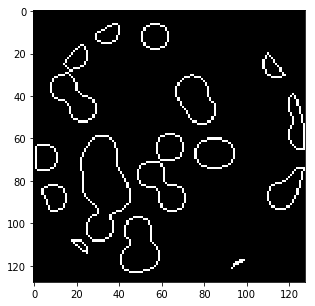

In [209]:
plt.figure(figsize=(5,5))
plt.imshow(data, cmap=plt.cm.gray);

#### `generate_synthetic_data()` 在做什么(What it is doing)

In [155]:
l=8; n_pts=5
rs = np.random.RandomState(0)

In [156]:
x, y = np.ogrid[0:l, 0:l]; x,y

(array([[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7]]), array([[0, 1, 2, 3, 4, 5, 6, 7]]))

In [170]:
x + y

array([[ 0,  1,  2,  3,  4,  5,  6,  7],
 [ 1,  2,  3,  4,  5,  6,  7,  8],
 [ 2,  3,  4,  5,  6,  7,  8,  9],
 [ 3,  4,  5,  6,  7,  8,  9, 10],
 [ 4,  5,  6,  7,  8,  9, 10, 11],
 [ 5,  6,  7,  8,  9, 10, 11, 12],
 [ 6,  7,  8,  9, 10, 11, 12, 13],
 [ 7,  8,  9, 10, 11, 12, 13, 14]])

In [157]:
(x - l/2) ** 2 

array([[ 16.],
 [  9.],
 [  4.],
 [  1.],
 [  0.],
 [  1.],
 [  4.],
 [  9.]])

In [59]:
(x - l/2) ** 2 + (y - l/2) ** 2

array([[ 32.,  25.,  20.,  17.,  16.,  17.,  20.,  25.],
 [ 25.,  18.,  13.,  10., 9.,  10.,  13.,  18.],
 [ 20.,  13., 8., 5., 4., 5., 8.,  13.],
 [ 17.,  10., 5., 2., 1., 2., 5.,  10.],
 [ 16., 9., 4., 1., 0., 1., 4., 9.],
 [ 17.,  10., 5., 2., 1., 2., 5.,  10.],
 [ 20.,  13., 8., 5., 4., 5., 8.,  13.],
 [ 25.,  18.,  13.,  10., 9.,  10.,  13.,  18.]])

In [60]:
mask_outer = (x - l/2) ** 2 + (y - l/2) ** 2 < (l/2) ** 2; mask_outer

array([[False, False, False, False, False, False, False, False],
 [False, False,  True,  True,  True,  True,  True, False],
 [False,  True,  True,  True,  True,  True,  True,  True],
 [False,  True,  True,  True,  True,  True,  True,  True],
 [False,  True,  True,  True,  True,  True,  True,  True],
 [False,  True,  True,  True,  True,  True,  True,  True],
 [False,  True,  True,  True,  True,  True,  True,  True],
 [False, False,  True,  True,  True,  True,  True, False]], dtype=bool)

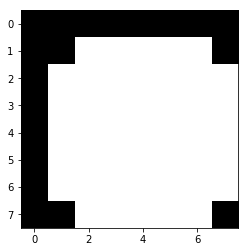

In [61]:
plt.imshow(mask_outer, cmap='gray')

In [62]:
mask = np.zeros((l, l))
mx,my = rs.randint(0, l, (2,n_pts))
mask[mx,my] = 1; mask

array([[ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
 [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
 [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
 [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
 [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
 [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.],
 [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
 [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.]])

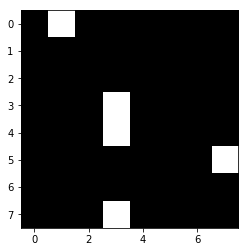

In [63]:
plt.imshow(mask, cmap='gray')

In [64]:
mask = ndimage.gaussian_filter(mask, sigma=l / n_pts)

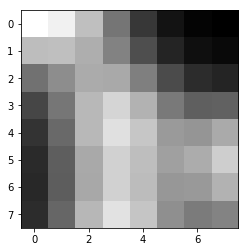

In [65]:
plt.imshow(mask, cmap='gray')

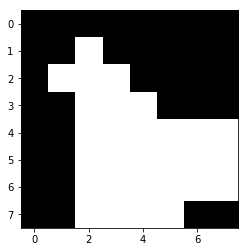

In [66]:
res = np.logical_and(mask > mask.mean(), mask_outer)
plt.imshow(res, cmap='gray');

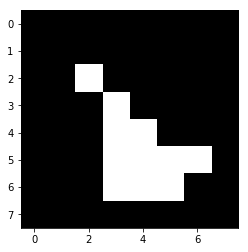

In [67]:
plt.imshow(ndimage.binary_erosion(res), cmap='gray');

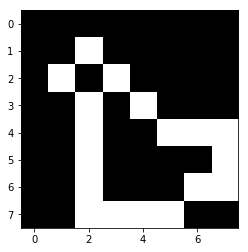

In [68]:
plt.imshow(res ^ ndimage.binary_erosion(res), cmap='gray');

### 生成投影(Generate Projections)

#### 代码(Code)

In [72]:
def _weights(x, dx=1, orig=0):
 x = np.ravel(x)
 floor_x = np.floor((x - orig) / dx)
 alpha = (x - orig - floor_x * dx) / dx
 return np.hstack((floor_x, floor_x + 1)), np.hstack((1 - alpha, alpha))


def _generate_center_coordinates(l_x):
 X, Y = np.mgrid[:l_x, :l_x].astype(np.float64)
 center = l_x / 2.
 X += 0.5 - center
 Y += 0.5 - center
 return X, Y

In [73]:
def build_projection_operator(l_x, n_dir):
 X, Y = _generate_center_coordinates(l_x)
 angles = np.linspace(0, np.pi, n_dir, endpoint=False)
 data_inds, weights, camera_inds = [], [], []
 data_unravel_indices = np.arange(l_x ** 2)
 data_unravel_indices = np.hstack((data_unravel_indices,
 data_unravel_indices))
 for i, angle in enumerate(angles):
 Xrot = np.cos(angle) * X - np.sin(angle) * Y
 inds, w = _weights(Xrot, dx=1, orig=X.min())
 mask = (inds >= 0) & (inds < l_x)
 weights += list(w[mask])
 camera_inds += list(inds[mask] + i * l_x)
 data_inds += list(data_unravel_indices[mask])
 proj_operator = sparse.coo_matrix((weights, (camera_inds, data_inds)))
 return proj_operator

#### 投影算子(Projection operator)

In [210]:
l = 128

In [211]:
proj_operator = build_projection_operator(l, l // 7)

In [212]:
proj_operator

<2304x16384 sparse matrix of type '<class 'numpy.float64'>'
	with 555378 stored elements in COOrdinate format>

维度(dimensions)：角度(angles，`l//7`)、位置(positions，`l`)、以及每个组合对应的一张图像(image，`l x l`)

In [213]:
proj_t = np.reshape(proj_operator.todense().A, (l//7,l,l,l))

第一个坐标(coordinate)对应直线的角度(angle)，第二个坐标对应直线的位置(location)。

角度索引(index)为 3 时，对应的所有直线(lines)：

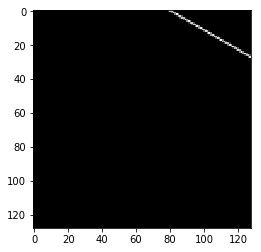

In [214]:
plt.imshow(proj_t[3,0], cmap='gray');

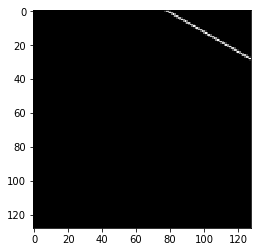

In [215]:
plt.imshow(proj_t[3,1], cmap='gray');

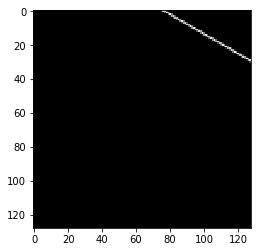

In [216]:
plt.imshow(proj_t[3,2], cmap='gray');

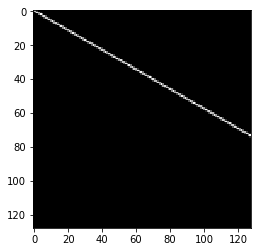

In [217]:
plt.imshow(proj_t[3,40], cmap='gray');

同一竖直位置(vertical location)为 40 的其他直线(lines)：